# **IIRFilter**
 

*   Mykola Liashuha
*   Jose Gonzalez Lopez



# Introduction
In this work ...


# Imports

In [1]:
import numpy as np #Numpy for calculations
import sklearn #Use this library to normalize
import math #For calculations
import scipy.signal
from scipy.io import wavfile #Read wav files
from matplotlib import pyplot as plt #Plots
from scipy.fft import fft, ifft,fftfreq #Fourier transform

In [2]:
from scipy.io import wavfile
samplerate, data = wavfile.read('string_2.wav') #Read the data stream and get samplerate
ALPHA=0.1 #Attenuation Factor
DELAY=1 #Time delay

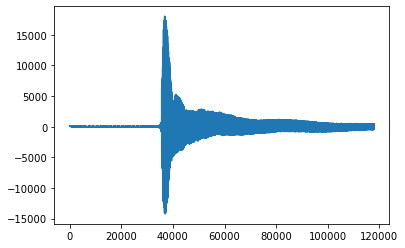

In [3]:
plt.plot(data)

In [30]:
def iir_step(x_orig, x, a, b, D, t):
    if t - D < 0:
#         print(f'step at {t}, D {D} with x_orig {x_orig[t]}; a {a}, b {b} => {a*x_orig[t]}')
        return a*x_orig[t]
    else:
#         print(f'step at {t}, D {D} with x_orig {x_orig[t]} and second {x[t-D]}; a {a}, b {b} => {a*x_orig[t] + b*x[t-D]}')
        return a*x_orig[t] + b*x[t-D]
    
def IIR(data, a, b, D):
    data_new = data.copy().astype('float32')
    for i in range(0, data_new.shape[0]):
        data_new[i] = iir_step(data, data_new, a, b, D, i)
    return data_new
    
def get_impulse_response(D, a, init=1.0):
    res = []
    res.append(init)
    
    for i in range(1, D):
        res.append(0)
    res.append(-a)
    return res


Impulse response A [0.1]
Impulse response B [1.0, 0, 0, -0.9]


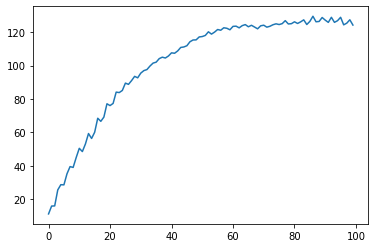

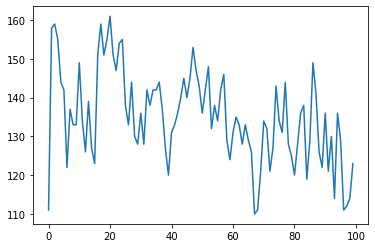

In [48]:
D = 3
A = 0.1
B = 0.9


a = [A]
b = get_impulse_response(D, B)


print('Impulse response A', a)
print('Impulse response B', b)

data_new = scipy.signal.lfilter(a, b, data)
plt.plot(data_new[:100])
plt.show()

plt.plot(data[:100])
plt.show()

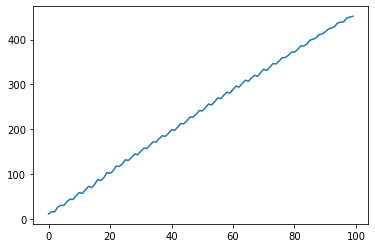

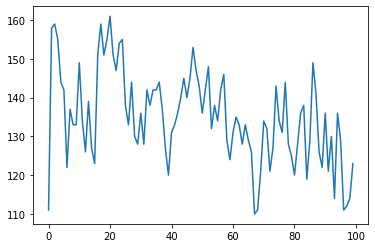

In [61]:

D = 3
A = 0.1
B = 1.0


data_new = IIR(data, A, B, D)

plt.plot(data_new[:100])
plt.show()

plt.plot(data[:100])
plt.show()

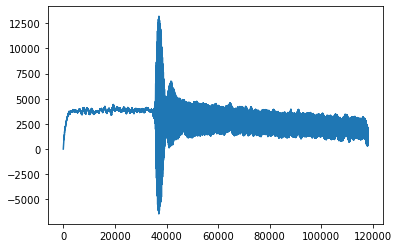

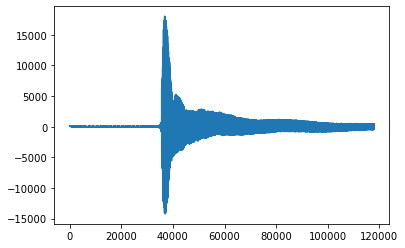

In [62]:
plt.plot(data_new)
plt.show()

plt.plot(data)
plt.show()

In [40]:
sample = data[:6]#np.array([15, 0, 20, 30, 10, 5, 4, 15, 40, 50])
print('sample', sample)

D = 1
A = 0.1
B = 0.3

a = [A]
b = get_impulse_response(D, B)


print('Impulse response A', a)
print('Impulse response B', b)

sample_scipy = scipy.signal.lfilter(a, b, sample)
print('scipy', sample_scipy)

sample_cust = IIR(sample, A, B, D)
print('custom', sample_cust)

sample [111 158 159 155 144 142]
Impulse response A [0.1]
Impulse response B [1.0, -0.3]
scipy [11.1      19.13     21.639    21.9917   20.99751  20.499253]
custom [11.1      19.130001 21.639    21.9917   20.997509 20.499252]


Impulse response A [0.1]
Impulse response B [1.0, 0, 0, 0, 0, 0, 0, -0.3]


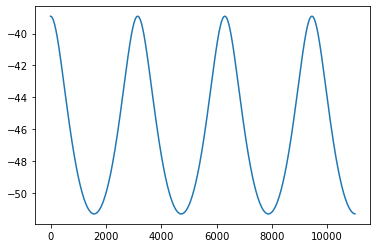

In [38]:
D = 7
A = 0.1
B = 0.3


a = [A]
b = get_impulse_response(D, B)

print('Impulse response A', a)
print('Impulse response B', b)

H, W = scipy.signal.freqz(a, b,fs=samplerate)
plt.plot(H,20*np.log(np.abs(W)+np.finfo(np.float32).eps))